# Customer Churn Prediction

## 1. Dataset Understanding

This project focuses on predicting customer churn using the Telco Customer Churn dataset.

The goal is to build a machine learning classification model that can identify customers who are likely to leave the company.

In this section, we inspect the dataset structure, data types, missing values, duplicate records, target distribution, and initial relationships between customer characteristics and churn.

In [1]:
import pandas as pd

df=pd.read_csv("Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
df.shape

(7043, 21)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df.describe(include="object")

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [6]:
df.duplicated().sum()

np.int64(0)

## 2. Data Quality and Cleaning

Before training the models, the dataset is examined for duplicate records, missing values, inconsistent values, and incorrect data types.

The `TotalCharges` column requires special attention because some records contain blank strings instead of numerical values.

In [7]:
df["TotalCharges"].str.strip().eq("").sum()

np.int64(11)

In [8]:
df[df["TotalCharges"].str.strip().eq("")][["tenure", "MonthlyCharges", "TotalCharges", "Churn"]]

,tenure,MonthlyCharges,TotalCharges,Churn
488,0,52.55,,No
753,0,20.25,,No
936,0,80.85,,No
1082,0,25.75,,No
1340,0,56.05,,No
3331,0,19.85,,No
3826,0,25.35,,No
4380,0,20.00,,No
5218,0,19.70,,No
6670,0,73.35,,No


## 3. Exploratory Data Analysis

The target variable and important customer characteristics are explored to understand the distribution of churn and identify potentially informative patterns.

The analysis focuses on churn distribution, contract type, and customer tenure.

In [9]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

### Contract Type vs Churn

Contract type is examined because customer commitment may be associated with churn behavior.

In [11]:
pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


### Tenure vs Churn

Customer tenure is analyzed to investigate whether the length of the customer relationship differs between customers who churn and those who remain.

In [12]:
df.groupby("Churn")["tenure"].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


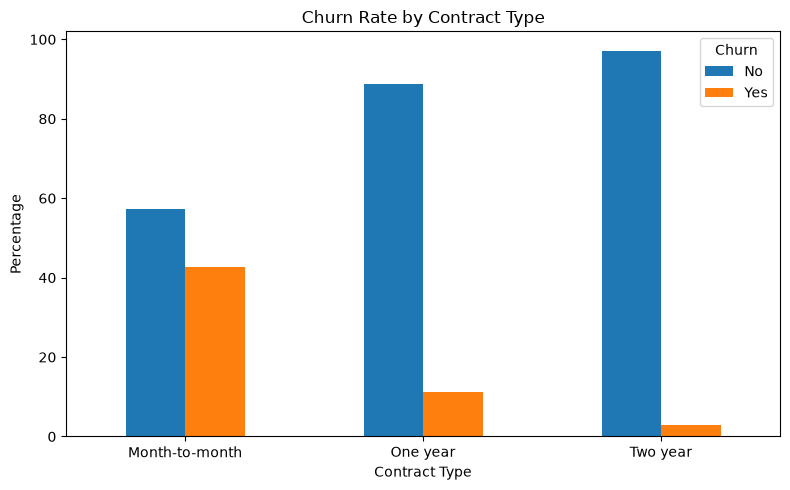

In [13]:
import matplotlib.pyplot as plt

churn_by_contract=pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
)*100

churn_by_contract.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

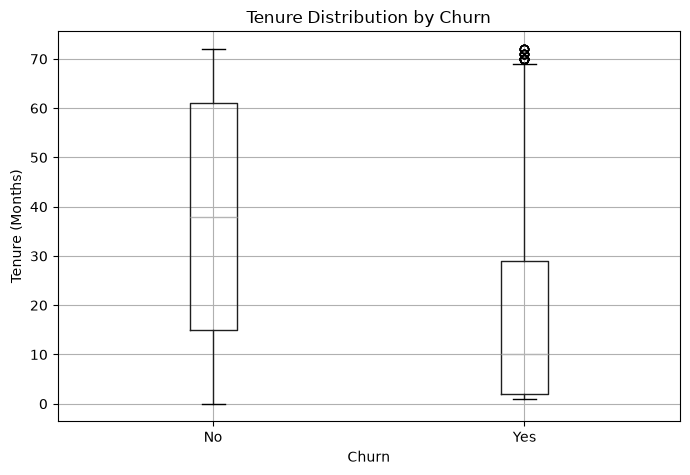

In [14]:
df.boxplot(
    column="tenure",
    by="Churn",
    figsize=(7, 5)
)

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.tight_layout()
plt.show()

In [15]:
import numpy as np

df["TotalCharges"]=pd.to_numeric(
    df["TotalCharges"].str.strip(),
    errors="coerce"
)

df[["TotalCharges", "tenure", "MonthlyCharges"]].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   TotalCharges    7032 non-null   float64
 1   tenure          7043 non-null   int64  
 2   MonthlyCharges  7043 non-null   float64
dtypes: float64(2), int64(1)
memory usage: 165.2 KB


In [16]:
df["TotalCharges"].isna().sum()

np.int64(11)

In [17]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)

In [18]:
df["TotalCharges"].isna().sum()

np.int64(0)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [20]:
df.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

## 4. Feature and Target Definition

The customer ID is removed because it is an identifier and does not provide meaningful predictive information.

The remaining variables are used as input features, while `Churn` is defined as the target variable.

The objective is to predict whether a customer will churn (`Yes`) or remain with the company (`No`).

In [21]:
X=df.drop(columns=["customerID", "Churn"])
y=df["Churn"]

In [22]:
X.shape, y.shape

((7043, 19), (7043,))

## 5. Train/Test Split

The dataset is divided into training and test sets using an 80/20 split.

Stratified sampling is used to preserve the original churn class distribution in both subsets.

The test set is kept separate and is used only for final model evaluation.

In [23]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [24]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (5634, 19)
X_test: (1409, 19)
y_train: (5634,)
y_test: (1409,)


In [25]:
print("Train:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)

Train:
Churn
No     73.464679
Yes    26.535321
Name: proportion, dtype: float64

Test:
Churn
No     73.456352
Yes    26.543648
Name: proportion, dtype: float64


## 6. Feature Types

The input features are divided into numerical and categorical variables.

Numerical features are standardized, while categorical features are imputed and transformed using one-hot encoding.

In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler

numeric_features = [
    "SeniorCitizen",
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

categorical_features = [
    col for col in X_train.columns
    if col not in numeric_features
]

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Categorical features: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


## 7. Preprocessing Pipeline

A preprocessing pipeline is created to apply the appropriate transformations to each feature type.

For numerical features:
- Missing values are imputed using the median.
- Features are standardized using StandardScaler.

For categorical features:
- Missing values are imputed using the most frequent value.
- Categories are converted into numerical representations using OneHotEncoder.

The preprocessing is integrated into the machine learning pipeline to ensure that transformations are learned only from the training data.

In [27]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

print(preprocessor)

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['SeniorCitizen', 'tenure', 'MonthlyCharges',
                                  'TotalCharges']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'Partner', 'Dependents',
                                  'PhoneService', 'MultipleLines',
                                  'InternetService', 'OnlineSecurity',
                                  'OnlineBackup',

In [28]:
X_train_processed=preprocessor.fit_transform(X_train)
X_test_processed=preprocessor.transform(X_test)

print("X_train shape:", X_train_processed.shape)
print("X_test shape:", X_test_processed.shape)

X_train shape: (5634, 45)
X_test shape: (1409, 45)


### Processed Feature Space

After preprocessing, the original 19 input features are transformed into 45 numerical features.

The increase is mainly caused by one-hot encoding of categorical variables.

## 8. Baseline Model: Logistic Regression

Logistic Regression is used as the baseline classification model.

It provides a simple and interpretable starting point for the churn prediction task and produces probability estimates that can later be used for threshold optimization.

In [29]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

print("Baseline model trained successfully.")

Baseline model trained successfully.


### Baseline Evaluation

The baseline model is evaluated on the held-out test set using accuracy, precision, recall, F1-score, and ROC-AUC.

Because churn detection is the main objective, recall and F1-score are particularly important evaluation metrics.

In [30]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

y_pred=baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Yes")
recall = recall_score(y_test, y_pred, pos_label="Yes")
f1 = f1_score(y_test, y_pred, pos_label="Yes")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.8055358410220014
Precision: 0.6572327044025157
Recall   : 0.5588235294117647
F1 Score : 0.6040462427745664


## Confusion Matrix

[[926 109]
 [165 209]]


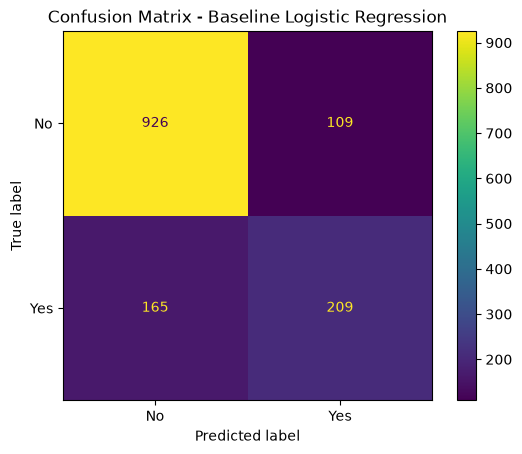

In [31]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["No", "Yes"]
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No", "Yes"]
)

disp.plot()
plt.title("Confusion Matrix - Baseline Logistic Regression")
plt.show()

## Exploratory Threshold Analysis

The following analysis shows how different classification thresholds affect precision, recall, and F1-score on the test set.

This analysis is exploratory only and is not used to select the final threshold.

The final threshold is selected separately using out-of-fold predictions from the training data.

In [32]:
from sklearn.metrics import roc_auc_score

y_proba=baseline_model.predict_proba(X_test)[:,1]

roc_auc = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_proba
)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8421349040274871


## 9. Cross-Validation

Five-fold stratified cross-validation is used to evaluate the stability of the Logistic Regression model.

Using multiple validation folds provides a more reliable estimate of model performance than relying on a single train/test split.

In [35]:
from sklearn.metrics import make_scorer, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_validate

scoring = {
    "accuracy": "accuracy",
    "precision": make_scorer(
        precision_score,
        pos_label="Yes"
    ),
    "recall": make_scorer(
        recall_score,
        pos_label="Yes"
    ),
    "f1": make_scorer(
        f1_score,
        pos_label="Yes"
    ),
    "roc_auc": "roc_auc"
}

cv_results = cross_validate(
    baseline_model,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("CV Accuracy :", cv_results["test_accuracy"].mean())
print("CV Precision:", cv_results["test_precision"].mean())
print("CV Recall   :", cv_results["test_recall"].mean())
print("CV F1       :", cv_results["test_f1"].mean())
print("CV ROC-AUC  :", cv_results["test_roc_auc"].mean())

CV Accuracy : 0.8042220579636595
CV Precision: 0.6576896316176918
CV Recall   : 0.5484949832775919
CV F1       : 0.5979882242724168
CV ROC-AUC  : 0.8456788054729003


## 10. Random Forest

Random Forest is evaluated as a nonlinear alternative to Logistic Regression.

The model can capture nonlinear relationships and interactions between customer characteristics that may not be represented directly by a linear model.

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model=Pipeline([
    ("preprocessor",preprocessor),
     ("model", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
     ))
])

rf_model.fit(X_train, y_train)

print("Random Forest trained successfully.")

Random Forest trained successfully.


In [37]:
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred_rf, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, y_pred_rf, pos_label="Yes"))
print(
    "ROC-AUC  :",
    roc_auc_score(
        (y_test == "Yes").astype(int),
        y_proba_rf
    )
)

Accuracy : 0.7835344215755855
Precision: 0.6185567010309279
Recall   : 0.48128342245989303
F1 Score : 0.5413533834586466
ROC-AUC  : 0.820602443876101


In [38]:
cv_rf = cross_validate(
    rf_model,
    X_train,
    y_train,
    cv=5,
    scoring=scoring,
    n_jobs=-1
)

print("CV Accuracy :", cv_rf["test_accuracy"].mean())
print("CV Precision:", cv_rf["test_precision"].mean())
print("CV Recall   :", cv_rf["test_recall"].mean())
print("CV F1       :", cv_rf["test_f1"].mean())
print("CV ROC-AUC  :", cv_rf["test_roc_auc"].mean())

CV Accuracy : 0.791265577201612
CV Precision: 0.6365664311334145
CV Recall   : 0.4969899665551839
CV F1       : 0.5580651434681416
CV ROC-AUC  : 0.8236771271073176


## 11. Hyperparameter Tuning

Grid Search with five-fold cross-validation is used to identify a better configuration for the Random Forest model.

The search focuses on the number of trees, maximum tree depth, and minimum number of samples required to split a node.

F1-score is used as the optimization metric because both precision and recall are important for churn prediction.

In [39]:
from sklearn.model_selection import GridSearchCV

rf_pipeline=Pipeline([
     ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

grid_search_rf = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring=scoring["f1"],
    n_jobs=-1
)

grid_search_rf.fit(X_train, y_train)

print("Best parameters:", grid_search_rf.best_params_)
print("Best CV F1:", grid_search_rf.best_score_)

Best parameters: {'model__max_depth': 10, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV F1: 0.5746768527255732


### Best Random Forest Configuration

The best hyperparameter configuration is selected based on the highest mean cross-validated F1-score on the training data.

## 12. Model Comparison

Three model configurations are compared using the same evaluation metrics:

- Logistic Regression
- Random Forest
- Tuned Random Forest

The comparison focuses on accuracy, precision, recall, F1-score, and ROC-AUC.

Since the primary business objective is identifying customers who are likely to churn, recall and F1-score receive particular attention.

In [40]:
best_rf=grid_search_rf.best_estimator_

y_pred_rf_tuned=best_rf.predict(X_test)
y_proba_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned, pos_label="Yes"))
print("Recall   :", recall_score(y_test, y_pred_rf_tuned, pos_label="Yes"))
print("F1 Score :", f1_score(y_test, y_pred_rf_tuned, pos_label="Yes"))
print(
    "ROC-AUC  :",
    roc_auc_score(
        (y_test == "Yes").astype(int),
        y_proba_rf_tuned
    )
)

Accuracy : 0.8069552874378992
Precision: 0.6722972972972973
Recall   : 0.5320855614973262
F1 Score : 0.5940298507462687
ROC-AUC  : 0.8392040610710688


### Comparison Results

Logistic Regression provides the strongest overall performance for the churn detection objective.

The tuned Random Forest achieves slightly higher accuracy and precision, but Logistic Regression provides higher recall, F1-score, and ROC-AUC.

Therefore, Logistic Regression is selected as the preferred model for further threshold optimization.

## 13. Threshold Optimization

The default classification threshold of 0.50 is not necessarily optimal for churn detection.

Because missing a customer who actually churns can be costly, different probability thresholds are evaluated to investigate the trade-off between precision and recall.

Threshold selection is performed using out-of-fold predictions generated only from the training data.

In [41]:
# Probabilities from Logistic Regression
y_proba = baseline_model.predict_proba(X_test)[:, 1]

thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_pred_threshold = np.where(
        y_proba >= threshold,
        "Yes",
        "No"
    )

    precision = precision_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    recall = recall_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    f1 = f1_score(
        y_test,
        y_pred_threshold,
        pos_label="Yes"
    )

    print(
        f"Threshold={threshold:.2f} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

Threshold=0.30 | Precision=0.519 | Recall=0.754 | F1=0.615
Threshold=0.35 | Precision=0.543 | Recall=0.706 | F1=0.614
Threshold=0.40 | Precision=0.568 | Recall=0.668 | F1=0.614
Threshold=0.45 | Precision=0.602 | Recall=0.615 | F1=0.608
Threshold=0.50 | Precision=0.657 | Recall=0.559 | F1=0.604
Threshold=0.55 | Precision=0.678 | Recall=0.463 | F1=0.550
Threshold=0.60 | Precision=0.718 | Recall=0.401 | F1=0.515


### Out-of-Fold Threshold Evaluation

Several classification thresholds are evaluated using out-of-fold predictions.

The threshold that produces the highest F1-score among the evaluated thresholds is selected.

In [42]:
from sklearn.model_selection import StratifiedKFold,cross_val_predict
from sklearn.metrics import f1_score, precision_score, recall_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Out-of-fold probabilities
y_train_proba_cv = cross_val_predict(
    baseline_model,
    X_train,
    y_train,
    cv=cv,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

thresholds = np.arange(0.20, 0.61, 0.05)

for threshold in thresholds:
    y_pred_threshold = np.where(
        y_train_proba_cv >= threshold,
        "Yes",
        "No"
    )

    precision = precision_score(
        y_train,
        y_pred_threshold,
        pos_label="Yes"
    )

    recall = recall_score(
        y_train,
        y_pred_threshold,
        pos_label="Yes"
    )

    f1 = f1_score(
        y_train,
        y_pred_threshold,
        pos_label="Yes"
    )

    print(
        f"Threshold={threshold:.2f} | "
        f"Precision={precision:.3f} | "
        f"Recall={recall:.3f} | "
        f"F1={f1:.3f}"
    )

Threshold=0.20 | Precision=0.475 | Recall=0.854 | F1=0.611
Threshold=0.25 | Precision=0.510 | Recall=0.817 | F1=0.628
Threshold=0.30 | Precision=0.541 | Recall=0.767 | F1=0.634
Threshold=0.35 | Precision=0.570 | Recall=0.717 | F1=0.635
Threshold=0.40 | Precision=0.594 | Recall=0.664 | F1=0.627
Threshold=0.45 | Precision=0.623 | Recall=0.601 | F1=0.612
Threshold=0.50 | Precision=0.653 | Recall=0.543 | F1=0.593
Threshold=0.55 | Precision=0.686 | Recall=0.486 | F1=0.569
Threshold=0.60 | Precision=0.711 | Recall=0.397 | F1=0.509


### Selected Threshold

A threshold of 0.35 provides the highest F1-score among the evaluated thresholds.

This threshold increases recall compared with the default 0.50 threshold, making the model more suitable for identifying customers at risk of churn.

## 14. Final Evaluation with Optimized Threshold

The selected threshold of 0.35 is applied to the previously unseen test set for final evaluation.

The test set is not used for threshold selection; it is reserved for measuring the final generalization performance of the selected model and threshold.

In [43]:
final_threshold = 0.35

y_pred_final = np.where(
    y_proba >= final_threshold,
    "Yes",
    "No"
)

print("Accuracy :", accuracy_score(y_test, y_pred_final))
print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_final,
        pos_label="Yes"
    )
)
print(
    "Recall   :",
    recall_score(
        y_test,
        y_pred_final,
        pos_label="Yes"
    )
)
print(
    "F1 Score :",
    f1_score(
        y_test,
        y_pred_final,
        pos_label="Yes"
    )
)

Accuracy : 0.7643718949609652
Precision: 0.5432098765432098
Recall   : 0.7058823529411765
F1 Score : 0.6139534883720931


## 15. ROC and Precision-Recall Curves

The ROC curve illustrates the trade-off between the true positive rate and false positive rate across different classification thresholds.

The Precision-Recall curve is particularly useful for churn prediction because the churn class is less frequent than the non-churn class.

These curves are used for model evaluation and visualization. The final threshold was selected separately using out-of-fold predictions on the training data.

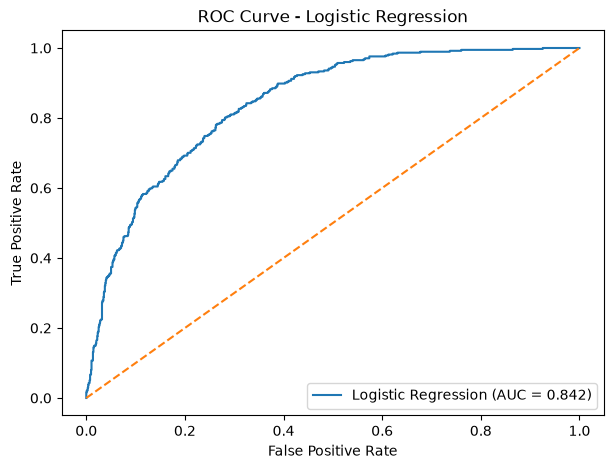

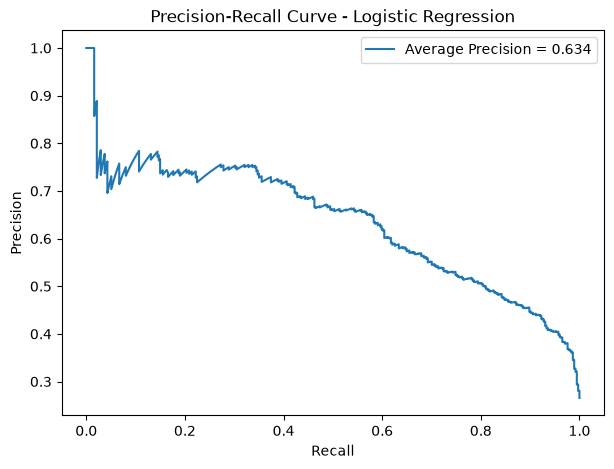

ROC-AUC: 0.8421349040274871
Average Precision: 0.6343385058492537


In [44]:
from sklearn.metrics import (
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score)
# Convert target to binary
y_test_binary = (y_test == "Yes").astype(int)

# ROC Curve
fpr, tpr, _ = roc_curve(
    y_test_binary,
    y_proba
)

roc_auc = roc_auc_score(
    y_test_binary,
    y_proba
)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {roc_auc:.3f})"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(
    y_test_binary,
    y_proba
)

average_precision = average_precision_score(
    y_test_binary,
    y_proba
)

plt.figure(figsize=(7, 5))
plt.plot(
    recall,
    precision,
    label=f"Average Precision = {average_precision:.3f}"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.legend()
plt.show()

print("ROC-AUC:", roc_auc)
print("Average Precision:", average_precision)

### Curve Analysis

The Logistic Regression model achieves a ROC-AUC of approximately 0.84, indicating good discrimination between customers who churn and those who remain.

The Precision-Recall curve provides additional insight into the trade-off between identifying churned customers and avoiding false positive predictions.

## 16. Feature Importance

Logistic Regression coefficients are analyzed to identify the features that have the strongest influence on the model's predictions.

Because the numerical features are standardized and categorical variables are one-hot encoded, the coefficients can be compared within the transformed feature space.

Positive coefficients are associated with higher predicted churn probability, while negative coefficients are associated with lower predicted churn probability.

These coefficients represent predictive associations learned by the model and should not be interpreted as causal relationships.

In [45]:
feature_names = baseline_model.named_steps["preprocessor"].get_feature_names_out()

coefficients = baseline_model.named_steps["model"].coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
1,num__tenure,-1.257539,1.257539
38,cat__Contract_Two year,-0.776594,0.776594
15,cat__InternetService_DSL,-0.648646,0.648646
16,cat__InternetService_Fiber optic,0.634195,0.634195
2,num__MonthlyCharges,-0.591863,0.591863
36,cat__Contract_Month-to-month,0.582883,0.582883
3,num__TotalCharges,0.536253,0.536253
39,cat__PaperlessBilling_No,-0.343227,0.343227
22,cat__OnlineBackup_No internet service,-0.300104,0.300104
17,cat__InternetService_No,-0.300104,0.300104


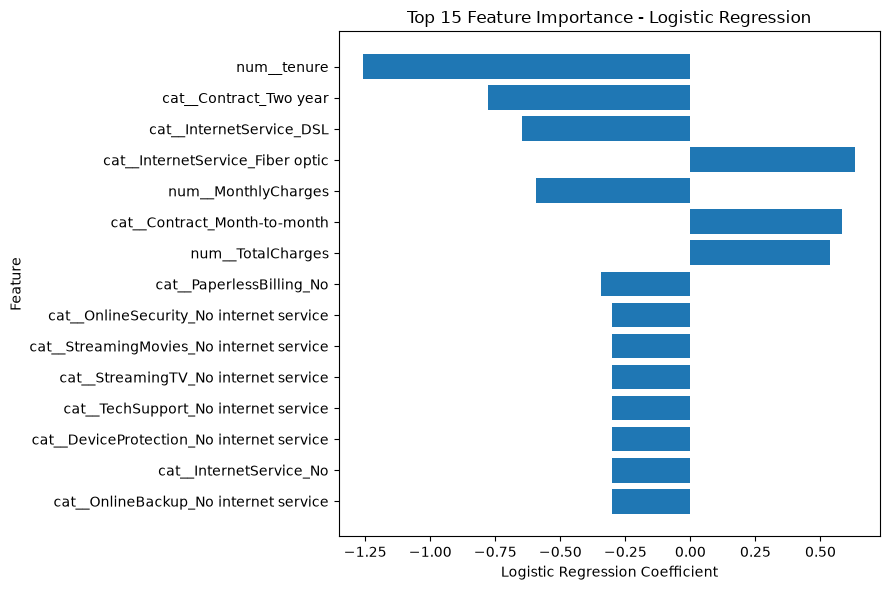

In [46]:
top_features = feature_importance.head(15).sort_values(
    "Absolute_Coefficient"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Logistic Regression Coefficient")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importance - Logistic Regression")

plt.tight_layout()
plt.show()

### Key Feature Insights

Tenure is the strongest feature by absolute coefficient magnitude.

Contract type is also highly influential. Month-to-month contracts have a positive coefficient, while two-year contracts have a negative coefficient.

Internet service type and customer charges also contribute substantially to the model's predictions.

In [49]:
from sklearn.metrics import confusion_matrix,classification_report

y_proba_final = baseline_model.predict_proba(X_test)[:, 1]

y_pred_final = np.where(
    y_proba_final >= 0.35,
    "Yes",
    "No"
)

print(classification_report(y_test, y_pred_final))

print("Confusion Matrix:")
print(confusion_matrix(
    y_test,
    y_pred_final,
    labels=["No", "Yes"]
))

              precision    recall  f1-score   support

          No       0.88      0.79      0.83      1035
         Yes       0.54      0.71      0.61       374

    accuracy                           0.76      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.76      0.77      1409

Confusion Matrix:
[[813 222]
 [110 264]]


## 17. Error Analysis

Error analysis is performed to understand where the final model makes incorrect predictions.

The predictions are categorized into:

- True Positive
- True Negative
- False Positive
- False Negative

Particular attention is given to False Negatives because these are customers who actually churned but were not identified by the model.

In [53]:
error_analysis = X_test.copy()

error_analysis["Actual"] = y_test.values
error_analysis["Predicted"] = y_pred_final
error_analysis["Churn_Probability"] = y_proba_final

error_analysis["Error_Type"] = np.select(
    [
        (error_analysis["Actual"] == "Yes") &
        (error_analysis["Predicted"] == "Yes"),

        (error_analysis["Actual"] == "No") &
        (error_analysis["Predicted"] == "No"),

        (error_analysis["Actual"] == "No") &
        (error_analysis["Predicted"] == "Yes"),

        (error_analysis["Actual"] == "Yes") &
        (error_analysis["Predicted"] == "No")
    ],
    [
        "True Positive",
        "True Negative",
        "False Positive",
        "False Negative"
    ],
    default="Unknown"
)

error_analysis["Error_Type"].value_counts()

Error_Type
True Negative     813
True Positive     264
False Positive    222
False Negative    110
Name: count, dtype: int64

### False Negative Analysis

The characteristics of False Negative customers are compared with the characteristics of all customers who actually churned.

This analysis helps identify potential patterns among churned customers that the model has difficulty detecting.

In [54]:
false_negatives = error_analysis[
    error_analysis["Error_Type"] == "False Negative"
]

false_negatives[
    [
        "tenure",
        "MonthlyCharges",
        "TotalCharges",
        "Contract",
        "InternetService",
        "PaymentMethod"
    ]
].describe(include="all")

,tenure,MonthlyCharges,TotalCharges,Contract,InternetService,PaymentMethod
count,110.000000,110.000000,110.000000,110,110,110
unique,NaN,NaN,NaN,3,3,4
top,NaN,NaN,NaN,Month-to-month,DSL,Mailed check
freq,NaN,NaN,NaN,69,47,32
mean,28.590909,62.928182,2391.716818,NaN,NaN,NaN
std,24.319093,31.048891,2504.764946,NaN,NaN,NaN
min,1.000000,18.950000,19.300000,NaN,NaN,NaN
25%,4.000000,45.950000,122.900000,NaN,NaN,NaN
50%,26.000000,58.525000,1552.775000,NaN,NaN,NaN
75%,52.750000,94.325000,4039.000000,NaN,NaN,NaN


### Error Analysis Findings

False Negative customers have a higher average tenure and lower average monthly charges compared with the overall group of churned customers.

This suggests that the model has more difficulty identifying churn among relatively long-tenured customers with lower monthly charges.

These observations describe patterns in model errors and should not be interpreted as causal relationships.

In [55]:
actual_churn = error_analysis[
    error_analysis["Actual"] == "Yes"
]

comparison = pd.DataFrame({
    "All Churned Customers": [
        actual_churn["tenure"].mean(),
        actual_churn["MonthlyCharges"].mean(),
        actual_churn["TotalCharges"].mean()
    ],
    "False Negatives": [
        false_negatives["tenure"].mean(),
        false_negatives["MonthlyCharges"].mean(),
        false_negatives["TotalCharges"].mean()
    ]
}, index=[
    "Average Tenure",
    "Average Monthly Charges",
    "Average Total Charges"
])

comparison

,All Churned Customers,False Negatives
Average Tenure,16.462567,28.590909
Average Monthly Charges,72.767112,62.928182
Average Total Charges,1400.716578,2391.716818


## Final Results

In [56]:
final_model = baseline_model
final_threshold = 0.35

final_accuracy = accuracy_score(y_test, y_pred_final)
final_precision = precision_score(
    y_test,
    y_pred_final,
    pos_label="Yes"
)
final_recall = recall_score(
    y_test,
    y_pred_final,
    pos_label="Yes"
)
final_f1 = f1_score(
    y_test,
    y_pred_final,
    pos_label="Yes"
)
final_roc_auc = roc_auc_score(
    (y_test == "Yes").astype(int),
    y_proba_final
)

print("Final Model: Logistic Regression")
print("Final Threshold:", final_threshold)
print("Final Test Accuracy:", final_accuracy)
print("Final Test Precision:", final_precision)
print("Final Test Recall:", final_recall)
print("Final Test F1:", final_f1)
print("Final Test ROC-AUC:", final_roc_auc)

Final Model: Logistic Regression
Final Threshold: 0.35
Final Test Accuracy: 0.7643718949609652
Final Test Precision: 0.5432098765432098
Final Test Recall: 0.7058823529411765
Final Test F1: 0.6139534883720931
Final Test ROC-AUC: 0.8421349040274871


# Final Results & Project Summary

## Final Model

The final selected model is Logistic Regression with a classification threshold of 0.35.

The threshold was selected using out-of-fold predictions on the training set to optimize F1-score. The test set was used only for final evaluation.

## Final Test Performance

| Metric | Score |
|---|---:|
| Accuracy | 76.44% |
| Precision | 54.32% |
| Recall | 70.59% |
| F1 Score | 61.40% |
| ROC-AUC | 84.21% |

## Model Selection

Several models were evaluated, including Logistic Regression, Random Forest, and tuned Random Forest.

Logistic Regression achieved the best overall balance for the business objective of identifying customers at risk of churn.

Although the tuned Random Forest achieved slightly higher accuracy and precision, Logistic Regression provided higher recall and F1-score.

Because missing a customer who is likely to churn can be costly, the final model uses a lower classification threshold of 0.35 to prioritize churn detection.

## Error Analysis

At the final threshold of 0.35:

- True Positives: 264
- True Negatives: 813
- False Positives: 222
- False Negatives: 110

The error analysis showed that false negatives tended to have higher average tenure and lower average monthly charges compared with the overall churned customers.

## Key Findings

- Contract type is an important predictor of customer churn.
- Month-to-month contracts are associated with higher predicted churn risk.
- Two-year contracts are associated with lower predicted churn risk.
- Tenure is one of the strongest predictive features in the Logistic Regression model.
- The model achieves an ROC-AUC of 84.21%.
- Lowering the classification threshold from 0.50 to 0.35 increased recall from 55.88% to 70.59%.